# Entropy row-action simplex-NMF on Moffett Field

This notebook runs the Moffett Field simplex-structured NMF experiment used by the paper. It mirrors the canonical script:

```bash
python -m experiments.simplex_nmf \
  --mode moffett \
  --profile paper \
  --data data/Moffet.mat
```

Run it from the repository root with the `uraf` kernel selected. The full run uses 800 outer iterations and writes the diagnostic figures to `figures_moffett/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from randomized_row_action import (
    entropy_row_action_simplex_nmf,
    load_moffett_mat,
    preprocess_hsi_global_scale,
)

In [2]:
moffett_path = Path("data/Moffet.mat")
if not moffett_path.exists():
    moffett_path = Path("../data/Moffet.mat")

X_moffett_raw = load_moffett_mat(moffett_path)
X_moffett, moffett_scale = preprocess_hsi_global_scale(X_moffett_raw)

result_moffett = entropy_row_action_simplex_nmf(
    X_moffett,
    rank=3,
    n_outer=800,
    eta_H0=1.0,
    eta_W0=0.01,
    eta_H_max=2.0,
    eta_W_max=0.1,
    growth=1.02,
    decay=0.5,
    line_search_mode="warmup",
    warmup_outer=40,
    max_backtracks=20,
    seed=123,
    verbose_every=100,
)

W_moffett = result_moffett.W
H_moffett = result_moffett.H
hist_moffett = result_moffett.history

W_moffett.shape, H_moffett.shape

outer= 100 | rel.err=5.314e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 200 | rel.err=5.314e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 300 | rel.err=5.314e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 400 | rel.err=5.314e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 500 | rel.err=5.314e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 600 | rel.err=5.313e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 700 | rel.err=5.313e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0
outer= 800 | rel.err=5.313e-02 | eta_H=1.455e-11 | eta_W=5.391e-06 | bt_H=0 | bt_W=0


((159, 3), (3, 2500))

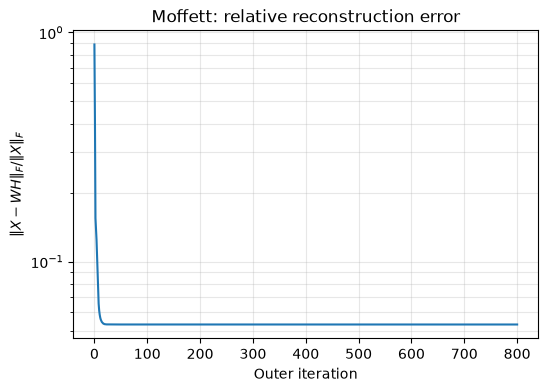

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(
    hist_moffett["outer_iteration"],
    hist_moffett["relative_error"],
)
ax.set_xlabel("Outer iteration")
ax.set_ylabel(r"$\|X-WH\|_F/\|X\|_F$")
ax.set_title("Moffett: relative reconstruction error")
ax.grid(True, which="both", alpha=0.3)
plt.show()

In [4]:
print("Maximum simplex sum violation:",
      hist_moffett["H_simplex_sum_violation"][-1])
print("H negativity violation:",
      hist_moffett["H_negativity_violation"][-1])
print("W negativity violation:",
      hist_moffett["W_negativity_violation"][-1])

Maximum simplex sum violation: 3.3306690738754696e-16
H negativity violation: 0.0
W negativity violation: 0.0


In [5]:
W_active = W_moffett
H_active = H_moffett
hist_active = hist_moffett
image_shape = (50, 50)
component_names = ["Water", "Vegetation", "Soil"]
title_prefix = "Moffett"

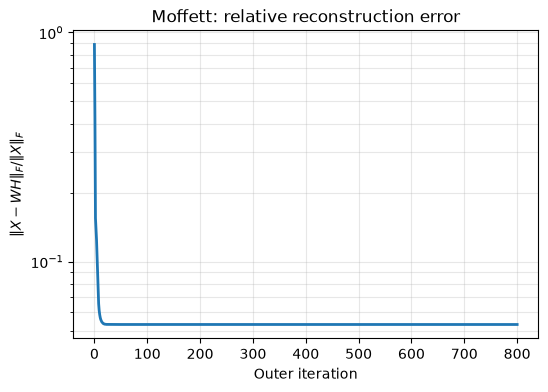

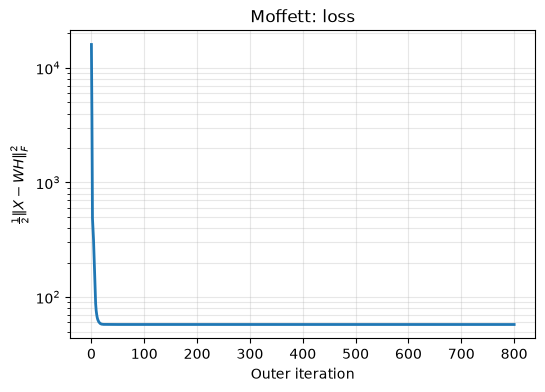

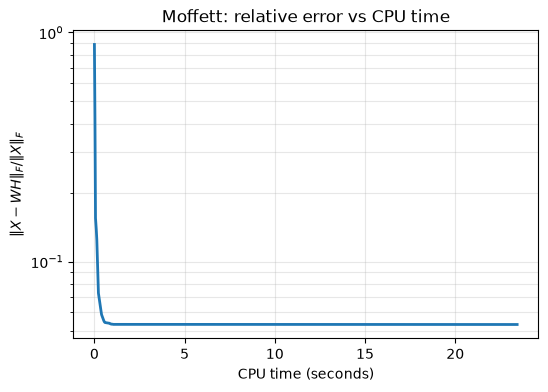

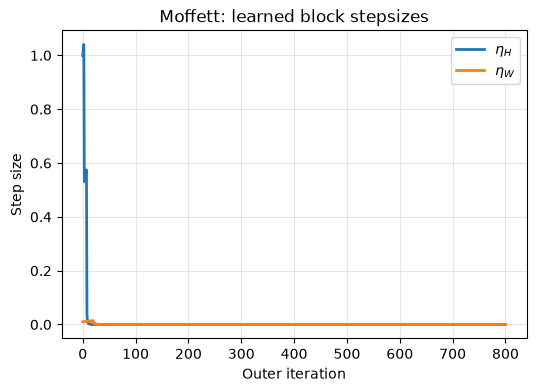

In [6]:
# Basic convergence plots
fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(hist_active["outer_iteration"], hist_active["relative_error"], linewidth=2)
ax.set_xlabel("Outer iteration")
ax.set_ylabel(r"$\|X-WH\|_F / \|X\|_F$")
ax.set_title(f"{title_prefix}: relative reconstruction error")
ax.grid(True, which="both", alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(hist_active["outer_iteration"], hist_active["loss"], linewidth=2)
ax.set_xlabel("Outer iteration")
ax.set_ylabel(r"$\frac{1}{2}\|X-WH\|_F^2$")
ax.set_title(f"{title_prefix}: loss")
ax.grid(True, which="both", alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(hist_active["time"], hist_active["relative_error"], linewidth=2)
ax.set_xlabel("CPU time (seconds)")
ax.set_ylabel(r"$\|X-WH\|_F / \|X\|_F$")
ax.set_title(f"{title_prefix}: relative error vs CPU time")
ax.grid(True, which="both", alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist_active["outer_iteration"], hist_active["eta_H"], label=r"$\eta_H$", linewidth=2)
ax.plot(hist_active["outer_iteration"], hist_active["eta_W"], label=r"$\eta_W$", linewidth=2)
ax.set_xlabel("Outer iteration")
ax.set_ylabel("Step size")
ax.set_title(f"{title_prefix}: learned block stepsizes")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [7]:
def sort_components_by_W_norm(W, H, ascending=True):
    norms = np.linalg.norm(W, axis=0)
    order = np.argsort(norms)
    if not ascending:
        order = order[::-1]
    return W[:, order], H[order, :], order, norms[order]


W_plot, H_plot, comp_order, comp_norms = sort_components_by_W_norm(
    W_active,
    H_active,
    ascending=True,
)

print("Component order by increasing ||W[:, k]||_2:", comp_order)
print("Sorted W-column norms:", comp_norms)

Component order by increasing ||W[:, k]||_2: [2 0 1]
Sorted W-column norms: [0.23273322 6.07443803 7.86916277]


Saved: figures_moffett/fig_moffett_abundance_maps_r3.pdf


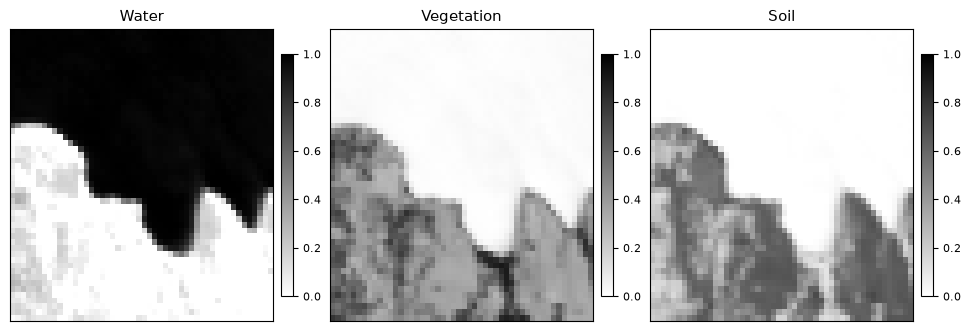

Saved: figures_moffett/fig_moffett_spectral_signatures_r3.pdf


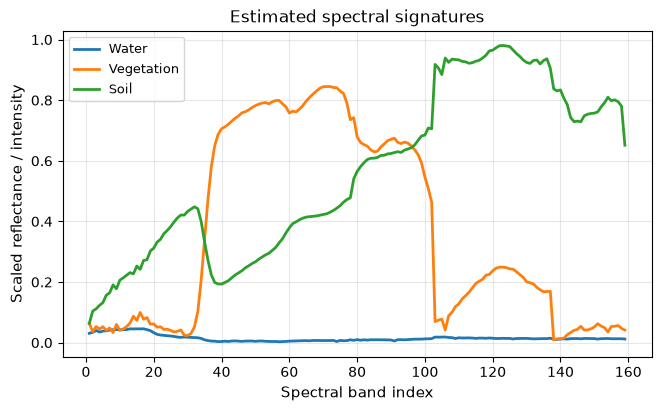

Saved: figures_moffett/fig_moffett_convergence_r3.pdf


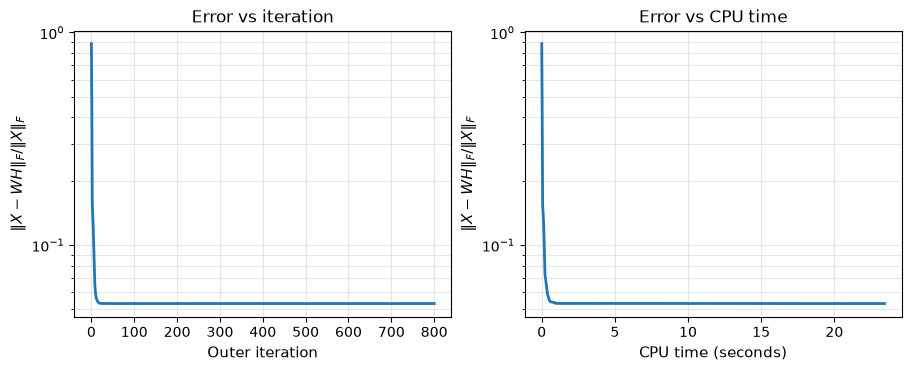

In [8]:
FIG_DIR = Path("figures_moffett")
FIG_DIR.mkdir(exist_ok=True)


def save_pdf(fig, filename, dpi=600):
    path = FIG_DIR / filename
    fig.savefig(path, format="pdf", dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    print(f"Saved: {path}")


def save_abundance_maps_pdf(
    H,
    filename="fig_moffett_abundance_maps_r3.pdf",
    image_shape=(50, 50),
    order="F",
    component_names=None,
    cmap="gray_r",
    dpi=600,
):
    rank, n_samples = H.shape
    height, width = image_shape
    if n_samples != height * width:
        raise ValueError(f"H has {n_samples} pixels, expected {height * width}.")
    if component_names is None:
        component_names = [f"Component {index + 1}" for index in range(rank)]

    fig, axes = plt.subplots(1, rank, figsize=(3.2 * rank, 3.2), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for component, ax in enumerate(axes):
        image = H[component].reshape(image_shape, order=order)
        shown = ax.imshow(image, cmap=cmap, vmin=0.0, vmax=1.0, interpolation="nearest", aspect="auto")
        ax.set_title(component_names[component], fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        colorbar = fig.colorbar(shown, ax=ax, fraction=0.046, pad=0.03)
        colorbar.ax.tick_params(labelsize=8)

    save_pdf(fig, filename, dpi=dpi)
    plt.show()


def save_endmember_spectra_pdf(
    W,
    filename="fig_moffett_spectral_signatures_r3.pdf",
    component_names=None,
    dpi=600,
):
    _, rank = W.shape
    if component_names is None:
        component_names = [f"Endmember {index + 1}" for index in range(rank)]
    bands = np.arange(1, W.shape[0] + 1)

    fig, ax = plt.subplots(figsize=(6.5, 4.0), constrained_layout=True)
    for component in range(rank):
        ax.plot(bands, W[:, component], linewidth=2.0, label=component_names[component])
    ax.set_xlabel("Spectral band index", fontsize=11)
    ax.set_ylabel("Scaled reflectance / intensity", fontsize=11)
    ax.set_title("Estimated spectral signatures", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, frameon=True)

    save_pdf(fig, filename, dpi=dpi)
    plt.show()


def save_moffett_convergence_pdf(
    hist,
    filename="fig_moffett_convergence_r3.pdf",
    dpi=600,
):
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), constrained_layout=True)
    axes[0].semilogy(hist["outer_iteration"], hist["relative_error"], linewidth=2.0)
    axes[0].set_xlabel("Outer iteration", fontsize=11)
    axes[0].set_ylabel(r"$\|X-WH\|_F/\|X\|_F$", fontsize=11)
    axes[0].set_title("Error vs iteration", fontsize=12)
    axes[0].grid(True, which="both", alpha=0.3)

    axes[1].semilogy(hist["time"], hist["relative_error"], linewidth=2.0)
    axes[1].set_xlabel("CPU time (seconds)", fontsize=11)
    axes[1].set_ylabel(r"$\|X-WH\|_F/\|X\|_F$", fontsize=11)
    axes[1].set_title("Error vs CPU time", fontsize=12)
    axes[1].grid(True, which="both", alpha=0.3)

    save_pdf(fig, filename, dpi=dpi)
    plt.show()


save_abundance_maps_pdf(
    H_plot,
    filename="fig_moffett_abundance_maps_r3.pdf",
    image_shape=image_shape,
    component_names=component_names,
)
save_endmember_spectra_pdf(
    W_plot,
    filename="fig_moffett_spectral_signatures_r3.pdf",
    component_names=component_names,
)
save_moffett_convergence_pdf(
    hist_active,
    filename="fig_moffett_convergence_r3.pdf",
)

## Scope

This is an illustration of row-action inner solvers inside an alternating nonconvex factorization scheme. The convex convergence theorems in the paper are not claimed to prove convergence of the complete alternating algorithm.